# Estimate Delta 01 — baseline regression

Full-sample robustness specification for June 1 through November 4, 2024:

\[
r_{TAN,t} = \alpha + \beta\,\Delta p_t + \gamma\,r_{SPY,t} + \varepsilon_t
\]

Inference uses Newey–West (HAC) standard errors with a Bartlett kernel, five lags, and finite-sample correction. This is a robustness estimate rather than the headline result because measurement noise in daily \(\Delta p\) can attenuate \(\beta\).

In [ ]:
from pathlib import Path

import pandas as pd
import statsmodels.api as sm

DATA_PATH = Path("data/daily_merged_tan_spy_polymarket_2024.csv")
RESULTS_PATH = Path("data/01_estimate_delta_baseline_results.csv")
START_DATE = pd.Timestamp("2024-06-01")
END_DATE = pd.Timestamp("2024-11-04")

In [ ]:
daily = pd.read_csv(DATA_PATH, parse_dates=["Date"]).set_index("Date").sort_index()

regression_data = daily.loc[
    START_DATE:END_DATE,
    ["TAN ret", "SPY ret", "Δp"],
].dropna()

assert not regression_data.empty
assert regression_data.index.min() >= START_DATE
assert regression_data.index.max() <= END_DATE
assert regression_data.index.is_unique

print(f"Observations: {len(regression_data)}")
print(f"Effective coverage: {regression_data.index.min().date()} to {regression_data.index.max().date()}")
regression_data.describe()

In [ ]:
y = regression_data["TAN ret"]
X = sm.add_constant(regression_data[["Δp", "SPY ret"]], has_constant="add")

baseline_model = sm.OLS(y, X).fit(
    cov_type="HAC",
    cov_kwds={
        "maxlags": 5,
        "kernel": "bartlett",
        "use_correction": True,
    },
    use_t=True,
)

baseline_model.summary()

In [ ]:
baseline_result = pd.DataFrame(
    {
        "specification": ["Baseline robustness: TAN on Δp and SPY"],
        "sample_start": [START_DATE.date().isoformat()],
        "sample_end": [END_DATE.date().isoformat()],
        "n_obs": [int(baseline_model.nobs)],
        "newey_west_lags": [5],
        "beta_delta_p": [baseline_model.params["Δp"]],
        "se_beta_delta_p": [baseline_model.bse["Δp"]],
        "p_value_beta_delta_p": [baseline_model.pvalues["Δp"]],
        "alpha": [baseline_model.params["const"]],
        "gamma_spy": [baseline_model.params["SPY ret"]],
        "r_squared": [baseline_model.rsquared],
    }
)

baseline_result.to_csv(RESULTS_PATH, index=False)

beta = baseline_result.loc[0, "beta_delta_p"]
beta_se = baseline_result.loc[0, "se_beta_delta_p"]
print(f"β = {beta:.6f}")
print(f"Newey–West SE(5) = {beta_se:.6f}")
print(f"Saved results to {RESULTS_PATH.resolve()}")

baseline_result

## Recorded robustness estimate

- **β on Δp:** −0.331311
- **Newey–West SE (5 lags):** 0.100980
- Observations: 108

This full-sample estimate is retained as the robustness column; noise in daily Δp can attenuate the coefficient.

## High-signal event-window regression

For each configured pre-election shock, the prediction-market change and ETF returns are measured over the same window. All three shocks occurred outside regular U.S. trading hours, so each window runs from the prior NYSE close to the next NYSE open. ETF gaps are adjusted for corporate-action factors. The event observations are pooled with the top decile of absolute daily `Δp` in the June 1–November 4 sample; reaction-date daily observations are excluded to avoid counting the same shock twice.

Event timestamps are sourced from **Tsang & Yang, arXiv:2603.03152**, as recorded in `config/events.json`.

In [ ]:
import json
from datetime import time as clock_time
from zoneinfo import ZoneInfo

CONFIG_PATH = Path("config/events.json")
ETF_PATH = Path("data/tan_spy_daily_2016_2024.csv")
POLYMARKET_PATH = Path("data/polymarket_trump_2024_yes_1min.csv")
HEADLINE_RESULTS_PATH = Path("data/01_estimate_delta_high_signal_results.csv")
EVENT_WINDOWS_PATH = Path("data/01_estimate_delta_event_windows.csv")

with CONFIG_PATH.open() as config_file:
    event_config = json.load(config_file)

etf_prices = pd.read_csv(ETF_PATH, parse_dates=["Date"])
polymarket_1min = pd.read_csv(POLYMARKET_PATH, parse_dates=["timestamp_utc"]).sort_values("timestamp_utc")

NY = ZoneInfo("America/New_York")
PRE_ELECTION_EVENTS = [
    "presidential_debate",
    "trump_assassination_attempt",
    "biden_dropout",
]

print("Timestamp source:", event_config["timestamp_source"])
print("Events:", PRE_ELECTION_EVENTS)

In [ ]:
trading_dates = pd.DatetimeIndex(
    sorted(
        set(etf_prices.loc[etf_prices["Ticker"] == "TAN", "Date"])
        & set(etf_prices.loc[etf_prices["Ticker"] == "SPY", "Date"])
    )
)

price_tables = {}
for ticker in ["TAN", "SPY"]:
    table = etf_prices.loc[etf_prices["Ticker"] == ticker].set_index("Date").sort_index().copy()
    table["Adj Open"] = table["Open"] * table["Adj Close"] / table["Close"]
    price_tables[ticker] = table

polymarket_price = polymarket_1min.set_index("timestamp_utc")["price"]


def ny_timestamp(date, hour, minute):
    return pd.Timestamp(
        year=date.year,
        month=date.month,
        day=date.day,
        hour=hour,
        minute=minute,
        tz=NY,
    ).tz_convert("UTC")


def build_outside_hours_event(event_key):
    event = event_config["events"][event_key]
    event_ts = pd.Timestamp(event["timestamp_utc"]).tz_convert("UTC")
    event_local = event_ts.tz_convert(NY)
    event_date = pd.Timestamp(event_local.date())
    is_trading_date = event_date in trading_dates
    hit_during_us_hours = (
        is_trading_date
        and clock_time(9, 30) <= event_local.time() < clock_time(16, 0)
    )
    if hit_during_us_hours:
        raise ValueError(f"{event_key} requires intraday ETF data for its first-two-hours window.")

    eligible_dates = trading_dates[trading_dates > event_date]
    if is_trading_date and event_local.time() < clock_time(9, 30):
        reaction_date = event_date
    else:
        reaction_date = eligible_dates[0]

    reaction_position = trading_dates.get_loc(reaction_date)
    prior_date = trading_dates[reaction_position - 1]
    window_start = ny_timestamp(prior_date.date(), 16, 0)
    window_end = ny_timestamp(reaction_date.date(), 9, 30)

    p_start = polymarket_price.asof(window_start)
    p_end = polymarket_price.asof(window_end)
    ticker_returns = {
        f"{ticker} ret": (
            price_tables[ticker].loc[reaction_date, "Adj Open"]
            / price_tables[ticker].loc[prior_date, "Adj Close"]
            - 1
        )
        for ticker in ["TAN", "SPY"]
    }

    return {
        "event": event_key,
        "label": event["label"],
        "event_timestamp_utc": event_ts,
        "Date": reaction_date,
        "window_start_utc": window_start,
        "window_end_utc": window_end,
        **ticker_returns,
        "TAN market-adjusted ret": ticker_returns["TAN ret"] - ticker_returns["SPY ret"],
        "p_start": p_start,
        "p_end": p_end,
        "Δp": p_end - p_start,
        "observation_type": "event_window",
    }


event_windows = pd.DataFrame(build_outside_hours_event(key) for key in PRE_ELECTION_EVENTS)
event_windows.to_csv(EVENT_WINDOWS_PATH, index=False)
event_windows

In [ ]:
signal_cutoff = regression_data["Δp"].abs().quantile(0.90)
reaction_dates = set(event_windows["Date"])

top_decile_days = (
    regression_data.loc[regression_data["Δp"].abs() >= signal_cutoff]
    .loc[lambda frame: ~frame.index.isin(reaction_dates)]
    .reset_index()
)
top_decile_days["observation_type"] = "top_decile_day"
top_decile_days["event"] = pd.NA

event_regression_rows = event_windows[
    ["Date", "TAN ret", "SPY ret", "Δp", "observation_type", "event"]
]

high_signal = (
    pd.concat(
        [
            top_decile_days[
                ["Date", "TAN ret", "SPY ret", "Δp", "observation_type", "event"]
            ],
            event_regression_rows,
        ],
        ignore_index=True,
    )
    .sort_values(["Date", "observation_type"])
    .reset_index(drop=True)
)

print(f"Full-sample |Δp| 90th-percentile cutoff: {signal_cutoff:.6f}")
print(f"Top-decile daily observations retained: {len(top_decile_days)}")
print(f"Event-window observations: {len(event_regression_rows)}")
high_signal

In [ ]:
headline_y = high_signal["TAN ret"]
headline_X = sm.add_constant(high_signal[["Δp", "SPY ret"]], has_constant="add")

headline_model = sm.OLS(headline_y, headline_X).fit(
    cov_type="HAC",
    cov_kwds={
        "maxlags": 5,
        "kernel": "bartlett",
        "use_correction": True,
    },
    use_t=True,
)

headline_model.summary()

In [ ]:
headline_result = pd.DataFrame(
    {
        "specification": ["High-signal headline: event windows plus top-decile |Δp| days"],
        "sample_start": [START_DATE.date().isoformat()],
        "sample_end": [END_DATE.date().isoformat()],
        "n_obs": [int(headline_model.nobs)],
        "event_window_obs": [len(event_regression_rows)],
        "top_decile_day_obs": [len(top_decile_days)],
        "abs_delta_p_cutoff": [signal_cutoff],
        "newey_west_lags": [5],
        "beta_delta_p": [headline_model.params["Δp"]],
        "se_beta_delta_p": [headline_model.bse["Δp"]],
        "p_value_beta_delta_p": [headline_model.pvalues["Δp"]],
        "alpha": [headline_model.params["const"]],
        "gamma_spy": [headline_model.params["SPY ret"]],
        "r_squared": [headline_model.rsquared],
        "delta_E_for_0_to_1": [headline_model.params["Δp"]],
    }
)
headline_result.to_csv(HEADLINE_RESULTS_PATH, index=False)

headline_beta = headline_result.loc[0, "beta_delta_p"]
headline_se = headline_result.loc[0, "se_beta_delta_p"]
print(f"Headline β = ΔE for a 0→1 probability jump = {headline_beta:.6f}")
print(f"Newey–West SE(5) = {headline_se:.6f}")
print(f"Saved event windows to {EVENT_WINDOWS_PATH.resolve()}")
print(f"Saved headline result to {HEADLINE_RESULTS_PATH.resolve()}")

headline_result

## Recorded headline estimate

- **Headline β = ΔE for a 0→1 probability jump:** −0.234202
- **Newey–West SE (5 lags):** 0.112716
- High-signal observations: 15 (3 event windows + 12 top-decile days, including ties at the 90th-percentile cutoff)
- Two-sided p-value: 0.059855

The baseline full-sample estimate remains the robustness result; this high-signal estimate is the headline result.

## Comparable-event anchor: 2016 election

Compute TAN's adjusted overnight gap from the November 8, 2016 close to the November 9 open, subtract SPY's corresponding gap, and scale by the supplied approximate probability surprise of **0.75**:

\[
\Delta E_{2016} = \frac{r^{gap}_{TAN} - r^{gap}_{SPY}}{0.75}.
\]

The 0.75 surprise is retained as the stated calibration assumption. For clarity, a literal move from 0.15 to 1.00 would equal 0.85, so the calculation below does not infer the surprise from those rounded endpoints.

In [ ]:
ANCHOR_RESULTS_PATH = Path("data/01_estimate_delta_2016_anchor.csv")
ANCHOR_PRIOR_DATE = pd.Timestamp("2016-11-08")
ANCHOR_REACTION_DATE = pd.Timestamp("2016-11-09")
PROBABILITY_SURPRISE_2016 = 0.75

anchor_gaps = {}
for ticker in ["TAN", "SPY"]:
    anchor_gaps[ticker] = (
        price_tables[ticker].loc[ANCHOR_REACTION_DATE, "Adj Open"]
        / price_tables[ticker].loc[ANCHOR_PRIOR_DATE, "Adj Close"]
        - 1
    )

market_adjusted_gap_2016 = anchor_gaps["TAN"] - anchor_gaps["SPY"]
delta_E_2016 = market_adjusted_gap_2016 / PROBABILITY_SURPRISE_2016

anchor_result = pd.DataFrame(
    {
        "prior_close_date": [ANCHOR_PRIOR_DATE.date().isoformat()],
        "reaction_open_date": [ANCHOR_REACTION_DATE.date().isoformat()],
        "tan_adjusted_gap": [anchor_gaps["TAN"]],
        "spy_adjusted_gap": [anchor_gaps["SPY"]],
        "tan_market_adjusted_gap": [market_adjusted_gap_2016],
        "probability_surprise": [PROBABILITY_SURPRISE_2016],
        "delta_E_2016": [delta_E_2016],
    }
)
anchor_result.to_csv(ANCHOR_RESULTS_PATH, index=False)

print(f"TAN adjusted gap: {anchor_gaps['TAN']:.6f}")
print(f"SPY adjusted gap: {anchor_gaps['SPY']:.6f}")
print(f"TAN market-adjusted gap: {market_adjusted_gap_2016:.6f}")
print(f"ΔE_2016: {delta_E_2016:.6f}")
print(f"Saved anchor result to {ANCHOR_RESULTS_PATH.resolve()}")

anchor_result

## Recorded 2016 anchor

- TAN adjusted overnight gap: **−0.092789**
- SPY adjusted overnight gap: **−0.008127**
- TAN market-adjusted gap: **−0.084662**
- Assumed probability surprise: **0.75**
- **ΔE_2016: −0.112883**

## Final comparison

The table below assembles all three estimates. The 2016 anchor has no independently estimable standard error: it is one event divided by an assumed probability surprise, so reporting a regression-style SE would imply unsupported precision. It is retained as a calibration anchor with `NaN` in the SE column.

In [ ]:
FINAL_TABLE_PATH = Path("data/01_estimate_delta_final_comparison.csv")

final_comparison = pd.DataFrame(
    [
        {
            "estimate": "Full-sample OLS",
            "delta_E": baseline_result.loc[0, "beta_delta_p"],
            "standard_error": baseline_result.loc[0, "se_beta_delta_p"],
            "n_obs": int(baseline_result.loc[0, "n_obs"]),
            "inference": "Newey–West, 5 lags",
            "role": "Robustness",
        },
        {
            "estimate": "Event-window high-signal subsample",
            "delta_E": headline_result.loc[0, "beta_delta_p"],
            "standard_error": headline_result.loc[0, "se_beta_delta_p"],
            "n_obs": int(headline_result.loc[0, "n_obs"]),
            "inference": "Newey–West, 5 lags",
            "role": "Headline / sizing",
        },
        {
            "estimate": "2016 comparable-event anchor",
            "delta_E": anchor_result.loc[0, "delta_E_2016"],
            "standard_error": float("nan"),
            "n_obs": 1,
            "inference": "SE not identifiable from one event",
            "role": "Calibration anchor",
        },
    ]
)

estimate_low = final_comparison["delta_E"].min()
estimate_high = final_comparison["delta_E"].max()
estimate_range_width = estimate_high - estimate_low
sizing_delta_E = headline_result.loc[0, "beta_delta_p"]

final_comparison.to_csv(FINAL_TABLE_PATH, index=False)

print(f"ΔE range: [{estimate_low:.6f}, {estimate_high:.6f}]")
print(f"Range width: {estimate_range_width:.6f}")
print(f"Sizing estimate (event-window): {sizing_delta_E:.6f}")
print(f"Saved final table to {FINAL_TABLE_PATH.resolve()}")

final_comparison

## Final readout

All three estimates are negative, so they agree on direction, but their magnitudes are materially dispersed:

- Full-sample OLS: **−0.331311** (SE **0.100980**)
- Event-window high-signal subsample: **−0.234202** (SE **0.112716**)
- 2016 comparable-event anchor: **−0.112883** (SE not identifiable)

The cross-method range is **[−0.331311, −0.112883]**, with width **0.218428**. This dispersion is itself a finding about design and signal quality. Consistent with the pre-specified hierarchy, use the event-window estimate **ΔE = −0.234202** for sizing.

## Bootstrap uncertainty and propagated hedge outcomes

The headline \(\Delta E=-0.234202\) comes from only 15 high-signal observations. Its reported HAC(5) standard error is 0.112716—nearly half the point estimate—so downstream hedge size and P&L should not be treated as known exactly.

This section uses a nonparametric **pairs bootstrap**: resample the 15 regression rows with replacement, re-estimate the same TAN-on-\(\Delta p\)-and-SPY regression, and repeat 10,000 times. The resulting \(\Delta E\) draws are then passed through the existing hedge and realized P&L calculations.

The bootstrap avoids relying on the HAC formula, but it does not remove all assumptions: it treats the observed 15 rows as exchangeable resampling units and does not solve potential serial dependence, event-selection, or model-specification risk.

In [ ]:
import numpy as np

BOOTSTRAP_REPS = 10_000
BOOTSTRAP_SEED = 20_260_721
BOOTSTRAP_DRAWS_PATH = Path("data/01_estimate_delta_bootstrap_draws.csv")

bootstrap_sample = high_signal[["TAN ret", "SPY ret", "Δp"]].dropna().reset_index(drop=True)
assert len(bootstrap_sample) == int(headline_model.nobs)

rng = np.random.default_rng(BOOTSTRAP_SEED)
X_bootstrap = np.column_stack(
    [
        np.ones(len(bootstrap_sample)),
        bootstrap_sample["Δp"].to_numpy(),
        bootstrap_sample["SPY ret"].to_numpy(),
    ]
)
y_bootstrap = bootstrap_sample["TAN ret"].to_numpy()

beta_draws = []
while len(beta_draws) < BOOTSTRAP_REPS:
    sample_index = rng.integers(0, len(bootstrap_sample), size=len(bootstrap_sample))
    X_resample = X_bootstrap[sample_index]
    y_resample = y_bootstrap[sample_index]

    # Require all three regressors to remain identified in a resample.
    if np.linalg.matrix_rank(X_resample) < X_resample.shape[1]:
        continue

    coefficients, *_ = np.linalg.lstsq(X_resample, y_resample, rcond=None)
    beta_draws.append(coefficients[1])

bootstrap_draws = pd.DataFrame(
    {
        "replication": np.arange(1, BOOTSTRAP_REPS + 1),
        "delta_E": beta_draws,
    }
)
bootstrap_draws.to_csv(BOOTSTRAP_DRAWS_PATH, index=False)

bootstrap_delta_E_summary = pd.DataFrame(
    {
        "statistic": ["point_estimate", "bootstrap_mean", "bootstrap_sd", "p2_5", "p50", "p97_5", "Pr_delta_E_lt_0"],
        "delta_E": [
            headline_beta,
            bootstrap_draws["delta_E"].mean(),
            bootstrap_draws["delta_E"].std(ddof=1),
            bootstrap_draws["delta_E"].quantile(0.025),
            bootstrap_draws["delta_E"].quantile(0.50),
            bootstrap_draws["delta_E"].quantile(0.975),
            (bootstrap_draws["delta_E"] < 0).mean(),
        ],
    }
)

print(f"Completed {len(bootstrap_draws):,} valid pairs-bootstrap replications.")
print(f"Saved ΔE draws to {BOOTSTRAP_DRAWS_PATH.resolve()}")
bootstrap_delta_E_summary

In [ ]:
BOOTSTRAP_PNL_PATH = Path("data/01_estimate_delta_bootstrap_pnl.csv")
BOOTSTRAP_PNL_SUMMARY_PATH = Path("data/01_estimate_delta_bootstrap_pnl_summary.csv")
HEDGE_SCENARIOS_PATH = Path("data/hedge03_scenarios.csv")
EXECUTION_COSTS_PATH = Path("data/hedge03_execution_costs.csv")

ENTRY_DATE = pd.Timestamp("2024-11-04")
ONE_DAY_ENDPOINT = pd.Timestamp("2024-11-06")
FIVE_DAY_ENDPOINT = pd.Timestamp("2024-11-12")

hedge_scenarios = pd.read_csv(HEDGE_SCENARIOS_PATH)[["scenario", "Q"]]
execution_costs = pd.read_csv(EXECUTION_COSTS_PATH)
entry_midpoint = execution_costs["entry_midpoint_probability"].iloc[0]
effective_half_spread = execution_costs["b_effective_half_spread"].iloc[0]
entry_ask = entry_midpoint + effective_half_spread

adjusted_close = (
    etf_prices.pivot(index="Date", columns="Ticker", values="Adj Close")
    .sort_index()
)
entry_tan_price = adjusted_close.loc[ENTRY_DATE, "TAN"]
tan_returns_by_horizon = {
    "1_day": adjusted_close.loc[ONE_DAY_ENDPOINT, "TAN"] / entry_tan_price - 1,
    "5_day": adjusted_close.loc[FIVE_DAY_ENDPOINT, "TAN"] / entry_tan_price - 1,
}

bootstrap_pnl_frames = []
for scenario in hedge_scenarios.itertuples(index=False):
    yes_contracts = -scenario.Q * bootstrap_draws["delta_E"]
    contract_pnl = yes_contracts * (1 - entry_ask)

    for horizon, tan_return in tan_returns_by_horizon.items():
        tan_pnl = scenario.Q * tan_return
        bootstrap_pnl_frames.append(
            pd.DataFrame(
                {
                    "replication": bootstrap_draws["replication"],
                    "delta_E": bootstrap_draws["delta_E"],
                    "scenario": scenario.scenario,
                    "horizon": horizon,
                    "yes_contracts": yes_contracts,
                    "tan_pnl": tan_pnl,
                    "contract_pnl": contract_pnl,
                    "hedged_pnl": tan_pnl + contract_pnl,
                    "hedged_pnl_pct_Q": (tan_pnl + contract_pnl) / scenario.Q,
                }
            )
        )

bootstrap_pnl = pd.concat(bootstrap_pnl_frames, ignore_index=True)
bootstrap_pnl.to_csv(BOOTSTRAP_PNL_PATH, index=False)

bootstrap_pnl_summary = (
    bootstrap_pnl.groupby(["scenario", "horizon"])["hedged_pnl_pct_Q"]
    .agg(
        mean="mean",
        median="median",
        sd="std",
        p2_5=lambda values: values.quantile(0.025),
        p97_5=lambda values: values.quantile(0.975),
        probability_loss=lambda values: (values < 0).mean(),
    )
    .reset_index()
)
bootstrap_pnl_summary.to_csv(BOOTSTRAP_PNL_SUMMARY_PATH, index=False)

print(f"Entry midpoint / ask proxy: {entry_midpoint:.6f} / {entry_ask:.6f}")
print(f"Saved propagated P&L draws to {BOOTSTRAP_PNL_PATH.resolve()}")
print(f"Saved P&L summary to {BOOTSTRAP_PNL_SUMMARY_PATH.resolve()}")
bootstrap_pnl_summary

## Bootstrap result

With seed `20260721`, the 10,000 pairs-bootstrap draws have:

- Mean \(\Delta E\): **−0.236865**
- Bootstrap SD: **0.115839**
- 95% percentile interval: **[−0.452643, 0.008060]**
- Probability of a non-negative \(\Delta E\): **2.83%**

The propagated P&L distribution is material even though the point estimate is negative:

- **One-day hedged P&L:** median **+0.92% of Q**; 95% interval **[−9.66%, +9.72%]**; loss probability **42.01%**.
- **Five-day hedged P&L:** median **−5.24% of Q**; 95% interval **[−15.82%, +3.56%]**; loss probability **88.28%**.

The percentage distribution is identical for the retail and institutional scenarios before execution frictions; the full draw-level file retains the corresponding contract quantity and dollar P&L for each scenario. These results quantify sampling uncertainty only and do not add uncertainty from price impact, the probability input, or the delayed equity-convergence mechanism.

Saved bootstrap uncertainty figure to /Users/nick/Desktop/Prediction Markets/figures/01_estimate_delta_bootstrap_uncertainty.png


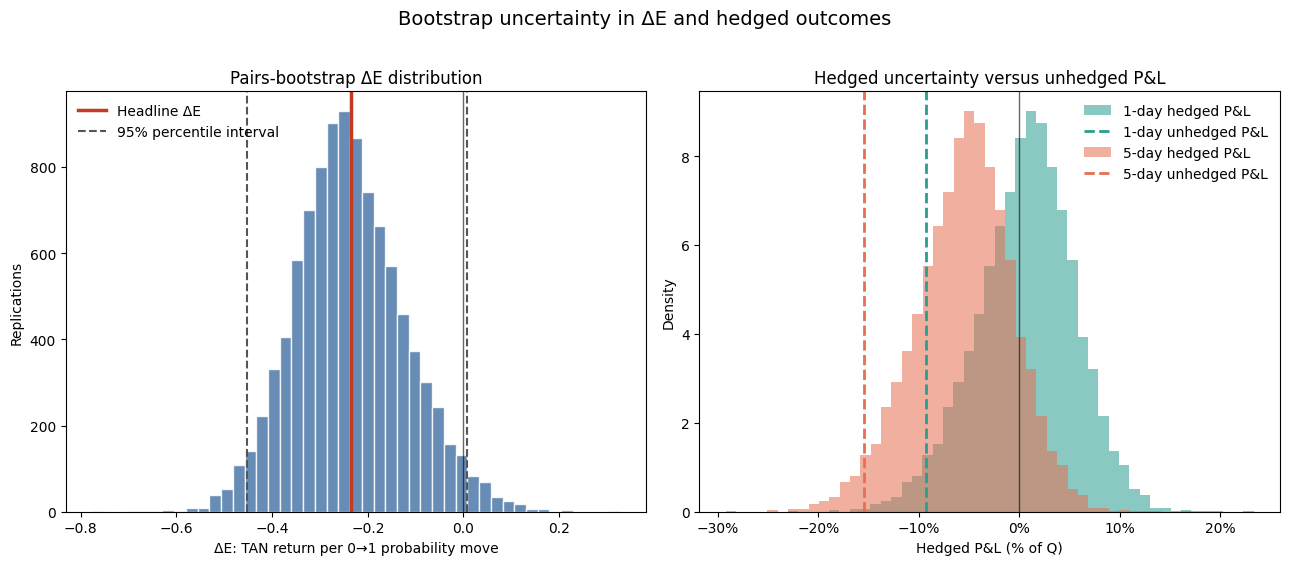

In [15]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

BOOTSTRAP_FIGURE_PATH = Path("figures/01_estimate_delta_bootstrap_uncertainty.png")
BOOTSTRAP_FIGURE_PATH.parent.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: distribution of the uncertainty in the headline estimate.
ax = axes[0]
ax.hist(
    bootstrap_draws["delta_E"],
    bins=45,
    color="#4C78A8",
    alpha=0.85,
    edgecolor="white",
)
ax.axvline(headline_beta, color="#C23B22", linewidth=2.5, label="Headline ΔE")
ax.axvline(
    bootstrap_draws["delta_E"].quantile(0.025),
    color="#555555",
    linestyle="--",
    linewidth=1.5,
    label="95% percentile interval",
)
ax.axvline(
    bootstrap_draws["delta_E"].quantile(0.975),
    color="#555555",
    linestyle="--",
    linewidth=1.5,
)
ax.axvline(0, color="black", linewidth=1, alpha=0.6)
ax.set_title("Pairs-bootstrap ΔE distribution")
ax.set_xlabel("ΔE: TAN return per 0→1 probability move")
ax.set_ylabel("Replications")
ax.legend(frameon=False)

# Right: the same ΔE draws propagated through the realized hedge P&L.
ax = axes[1]
retail_pnl = bootstrap_pnl.loc[bootstrap_pnl["scenario"].eq("Q_retail")]
for horizon, color, label in [
    ("1_day", "#2A9D8F", "1-day hedged P&L"),
    ("5_day", "#E76F51", "5-day hedged P&L"),
]:
    ax.hist(
        retail_pnl.loc[retail_pnl["horizon"].eq(horizon), "hedged_pnl_pct_Q"],
        bins=45,
        density=True,
        alpha=0.55,
        color=color,
        label=label,
    )
    # The unhedged result is deterministic for a fixed TAN position, so show it
    # as a vertical reference line rather than an artificial distribution.
    ax.axvline(
        tan_returns_by_horizon[horizon],
        color=color,
        linestyle="--",
        linewidth=2,
        label=f"{horizon.replace('_', '-')} unhedged P&L",
    )
ax.axvline(0, color="black", linewidth=1, alpha=0.6)
ax.set_title("Hedged uncertainty versus unhedged P&L")
ax.set_xlabel("Hedged P&L (% of Q)")
ax.set_ylabel("Density")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(frameon=False)

fig.suptitle("Bootstrap uncertainty in ΔE and hedged outcomes", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(BOOTSTRAP_FIGURE_PATH, dpi=300, bbox_inches="tight")

print(f"Saved bootstrap uncertainty figure to {BOOTSTRAP_FIGURE_PATH.resolve()}")
plt.show()